# Insurance Quote Acceptance Modeling and Discount Optimization

**Dataset:** `sompo_model_ready.xlsx`  
**Target:** `y_bin` (`1 = Accepted`, `0 = Declined`)

This notebook is built with the following design principles:

- the held-out test set is isolated before preprocessing,
- preprocessing is learned on training data only,
- imbalance is handled explicitly during model development,
- model comparison uses both ranking and class-sensitive metrics,
- threshold tuning is done on out-of-fold training predictions, not on the test set,
- the final business layer uses model-based discount simulation and budget-constrained allocation.

In [1]:
# ============================================================
# Global imports and notebook configuration
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from typing import Dict, List, Tuple

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve

# Optional libraries
LIGHTGBM_AVAILABLE = True
PYGAM_AVAILABLE = True

try:
    from lightgbm import LGBMClassifier
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from pygam import LogisticGAM, s
except Exception:
    PYGAM_AVAILABLE = False

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
TEST_SIZE = 0.15

print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("pyGAM available   :", PYGAM_AVAILABLE)

LightGBM available: True
pyGAM available   : False


## Section 1: Data Loading, Leakage Control, and Train/Test Split

This section does only four things:

1. loads the modeling dataset,
2. validates the target and identifier columns,
3. removes only certain leakage or non-predictive identifier fields,
4. creates a stratified hold-out test set.

In [2]:
# ============================================================
# Section 1: Data loading and safe split
# ============================================================

df_raw = pd.read_excel("sompo_model_ready.xlsx").copy()
print("Raw shape:", df_raw.shape)

required_cols = ["y_bin", "teklif_numarasi"]
missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

y_complete = df_raw["y_bin"].astype(int)
ids_complete = df_raw["teklif_numarasi"].copy()

drop_cols = ["teklif_onay_durumu", "y_bin", "teklif_numarasi"]
X_complete = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).copy()

X_train_raw, X_test_raw, y_train, y_test, ids_train, ids_test = train_test_split(
    X_complete,
    y_complete,
    ids_complete,
    test_size=TEST_SIZE,
    stratify=y_complete,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train_raw.shape)
print("Test shape :", X_test_raw.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Raw shape: (19085, 15)
Train shape: (16222, 12)
Test shape : (2863, 12)

Train class distribution:
y_bin
0    0.8756
1    0.1244
Name: proportion, dtype: float64

Test class distribution:
y_bin
0    0.8757
1    0.1243
Name: proportion, dtype: float64


## Section 2: Feature Engineering, Imputation, Encoding, and Stability-Based Screening

This section is designed for tabular insurance-style data and preserves train/test discipline.

Main choices:
- premium is log-transformed and represented once,
- `ilce` missingness is treated as its own category rather than globally imputed,
- only theory-guided interactions are added,
- imputation and encoding are learned on training data only,
- feature screening uses repeated stability selection.

In [3]:
# ============================================================
# Section 2: Feature engineering and preprocessing
# ============================================================

class SompoFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.portfoy_levels_ = None
        self.sigortali_levels_ = None

    def fit(self, X, y=None):
        X = X.copy()

        if "portfoy_ayrimi" in X.columns:
            self.portfoy_levels_ = (
                pd.Series(X["portfoy_ayrimi"], dtype="object")
                .dropna()
                .astype(str)
                .sort_values()
                .unique()
                .tolist()
            )

        if "sigortali_tipi" in X.columns:
            self.sigortali_levels_ = (
                pd.Series(X["sigortali_tipi"], dtype="object")
                .dropna()
                .astype(str)
                .sort_values()
                .unique()
                .tolist()
            )

        return self

    def transform(self, X):
        X = X.copy()

        # Premium transformation
        if "log_teklif_primi" not in X.columns and "teklif_primi" in X.columns:
            X["log_teklif_primi"] = np.log1p(np.clip(X["teklif_primi"], a_min=0, a_max=None))

        if "log_teklif_primi" in X.columns and "teklif_primi" in X.columns:
            X = X.drop(columns=["teklif_primi"])

        # Geography-specific missing handling
        if "ilce" in X.columns:
            X["ilce"] = X["ilce"].astype("object")
            X["ilce"] = X["ilce"].where(X["ilce"].notna(), "MISSING_ILCE")

        # Theory-guided interactions
        if (
            self.portfoy_levels_ is not None
            and "log_teklif_primi" in X.columns
            and "portfoy_ayrimi" in X.columns
        ):
            port_series = X["portfoy_ayrimi"].astype("object").astype(str)
            for lvl in self.portfoy_levels_:
                X[f"int_logprem_portfoy__{lvl}"] = X["log_teklif_primi"] * (port_series == lvl).astype(int)

        if (
            self.sigortali_levels_ is not None
            and "log_teklif_primi" in X.columns
            and "sigortali_tipi" in X.columns
        ):
            sig_series = X["sigortali_tipi"].astype("object").astype(str)
            for lvl in self.sigortali_levels_:
                X[f"int_logprem_sigortali__{lvl}"] = X["log_teklif_primi"] * (sig_series == lvl).astype(int)

        if {"trafik_basamak_kodu", "hasarsizlik_indirimi_kademesi"}.issubset(X.columns):
            X["risk_interaction"] = (
                pd.to_numeric(X["trafik_basamak_kodu"], errors="coerce")
                * pd.to_numeric(X["hasarsizlik_indirimi_kademesi"], errors="coerce")
            )

        return X

feature_engineer = SompoFeatureEngineer()

X_train_fe = feature_engineer.fit_transform(X_train_raw, y_train)
X_test_fe  = feature_engineer.transform(X_test_raw)
X_all_fe   = feature_engineer.transform(X_complete)

num_cols = X_train_fe.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train_fe.select_dtypes(exclude=["number"]).columns.tolist()

geo_cat_cols = [c for c in cat_cols if c == "ilce"]
std_cat_cols = [c for c in cat_cols if c != "ilce"]

try:
    ohe_std = OneHotEncoder(drop="first", handle_unknown="ignore", min_frequency=0.01, sparse_output=False)
    ohe_geo = OneHotEncoder(drop="first", handle_unknown="ignore", min_frequency=0.01, sparse_output=False)
except TypeError:
    ohe_std = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)
    ohe_geo = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

std_cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ohe_std)
])

geo_cat_pipeline = Pipeline([
    ("encoder", ohe_geo)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat_std", std_cat_pipeline, std_cat_cols),
        ("cat_geo", geo_cat_pipeline, geo_cat_cols)
    ],
    remainder="drop"
)

X_train_p = preprocessor.fit_transform(X_train_fe)
X_test_p  = preprocessor.transform(X_test_fe)
X_all_p   = preprocessor.transform(X_all_fe)

feature_names = pd.Index(preprocessor.get_feature_names_out())

print("Feature engineered train shape:", X_train_fe.shape)
print("Processed train shape         :", X_train_p.shape)
print("Processed test shape          :", X_test_p.shape)
print("Number of processed features  :", len(feature_names))

Feature engineered train shape: (16222, 18)
Processed train shape         : (16222, 53)
Processed test shape          : (2863, 53)
Number of processed features  : 53


In [4]:
# ============================================================
# Section 2B: No explicit feature screening
# ============================================================

selected_feature_names = feature_names.tolist()

X_train_b = X_train_p.copy()
X_test_b  = X_test_p.copy()
X_all_b   = X_all_p.copy()

print("No explicit feature screening applied.")
print("Selected features:", len(selected_feature_names))
print("\nFinal train matrix:", X_train_b.shape)
print("Final test matrix :", X_test_b.shape)

No explicit feature screening applied.
Selected features: 53

Final train matrix: (16222, 53)
Final test matrix : (2863, 53)


Training matrix used for screening: (16222, 53)


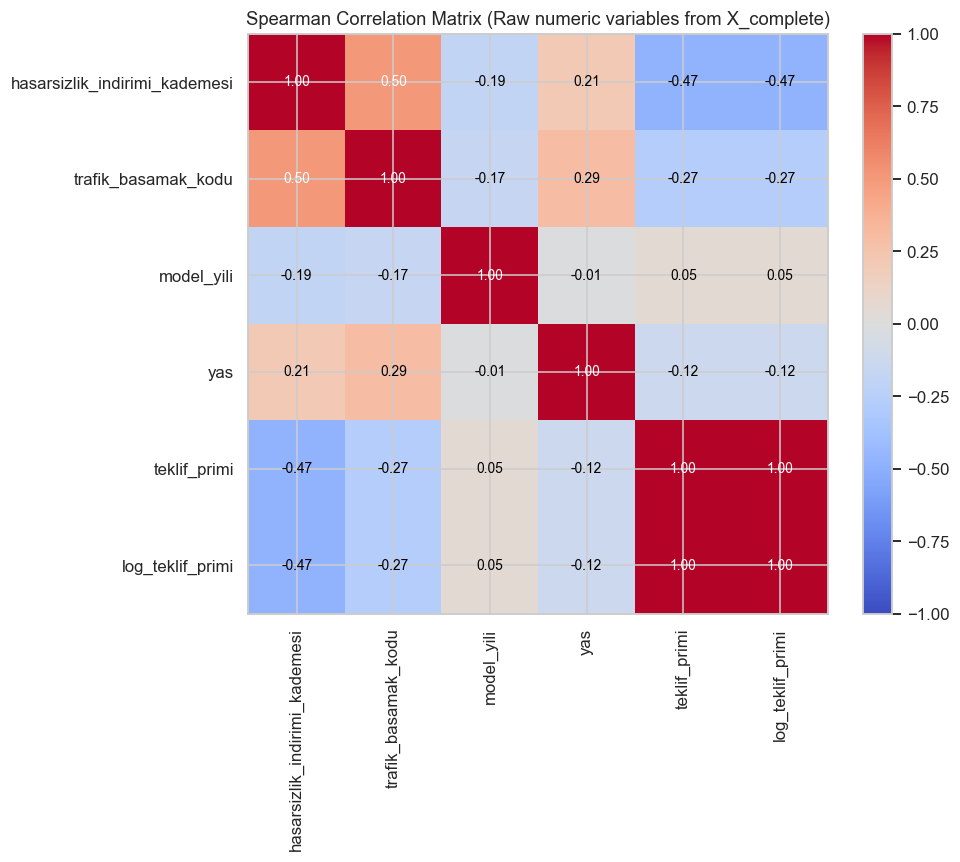

Top correlated pairs:


,var_1,var_2,spearman_rho,abs_rho
0,log_teklif_primi,teklif_primi,1.000000,1.000000
1,hasarsizlik_indirimi_kademesi,trafik_basamak_kodu,0.504780,0.504780
2,hasarsizlik_indirimi_kademesi,teklif_primi,-0.471168,0.471168
3,hasarsizlik_indirimi_kademesi,log_teklif_primi,-0.471168,0.471168
4,trafik_basamak_kodu,yas,0.292436,0.292436
5,teklif_primi,trafik_basamak_kodu,-0.271591,0.271591
6,log_teklif_primi,trafik_basamak_kodu,-0.271591,0.271591
7,hasarsizlik_indirimi_kademesi,yas,0.207038,0.207038
8,hasarsizlik_indirimi_kademesi,model_yili,-0.190192,0.190192
9,model_yili,trafik_basamak_kodu,-0.171048,0.171048


Top screening features:


,feature,mutual_information,gini_importance,mi_rank,gini_rank,avg_rank
0,num__int_logprem_sigortali__ÖZEL,0.015217,0.068607,4.0,4.0,4.0
1,num__int_logprem_sigortali__TÜZEL,0.019832,0.065169,3.0,5.0,4.0
2,num__int_logprem_portfoy__YENİLEME,0.023246,0.040738,2.0,9.0,5.5
3,cat_std__portfoy_ayrimi_YENİLEME,0.025065,0.034473,1.0,11.0,6.0
4,num__risk_interaction,0.015064,0.050933,5.0,8.0,6.5
5,num__yas,0.012002,0.056294,8.0,7.0,7.5
6,num__log_teklif_primi,0.003851,0.115634,15.0,1.0,8.0
7,num__int_logprem_portfoy__İLK DEFA SİGORTALI,0.012082,0.032287,7.0,12.0,9.5
8,num__hasarsizlik_indirimi_kademesi,0.007806,0.038697,11.0,10.0,10.5
9,cat_std__yakit_tipi_DIZEL,0.004675,0.022578,13.0,13.0,13.0


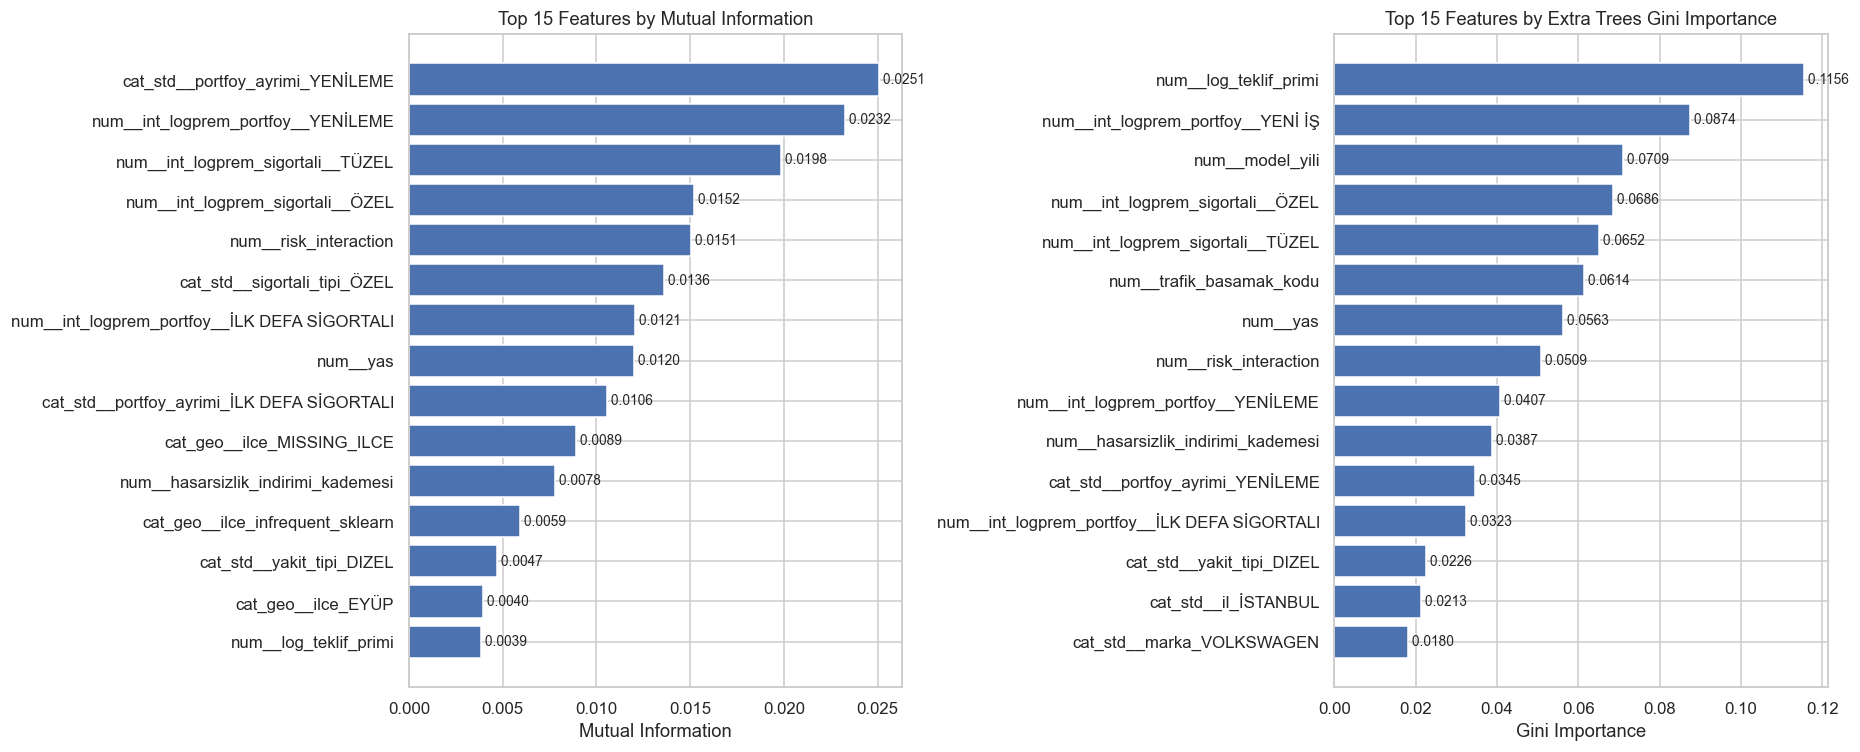

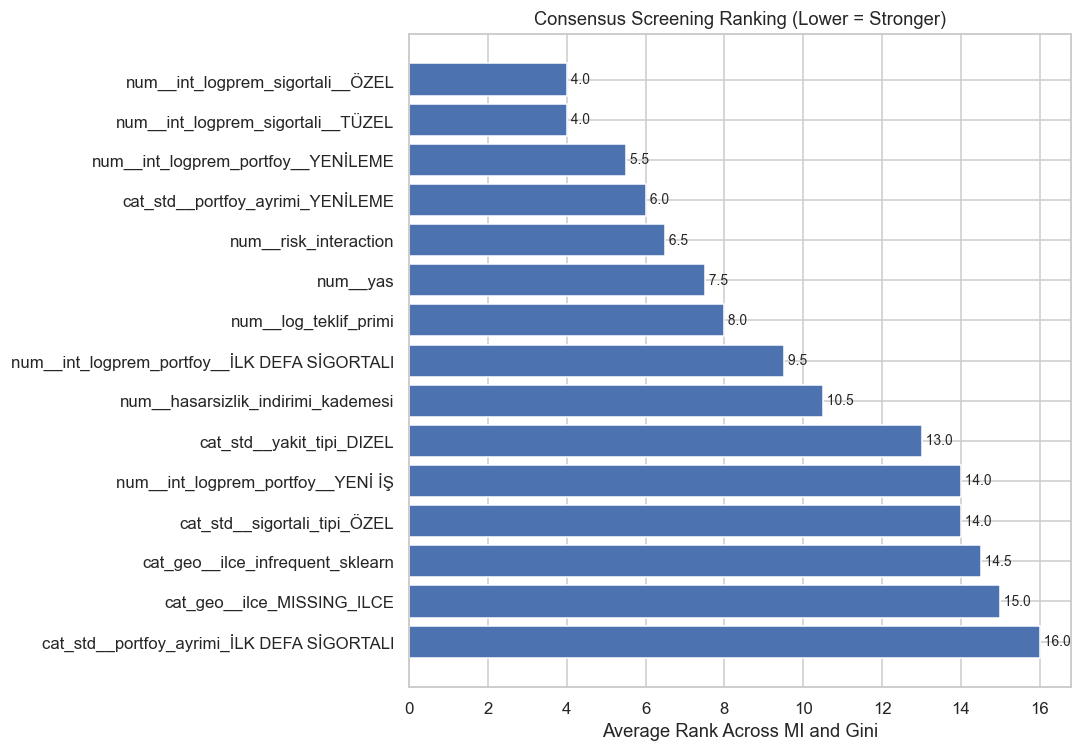

Section 2 screening diagnostics completed.


In [5]:
# ============================================================
# Section 2C: Feature Screening Diagnostics
# - Correlation matrix with numeric values in cells
# - Mutual Information screening
# - Extra Trees Gini importance screening
# - Figures with values on bars
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif

# ------------------------------------------------------------
# 0. Resolve available objects
# ------------------------------------------------------------
if "X_train_b" in globals():
    X_train_screen = pd.DataFrame(X_train_b, columns=selected_feature_names).reset_index(drop=True)
elif "X_train_p" in globals():
    X_train_screen = pd.DataFrame(X_train_p, columns=selected_feature_names).reset_index(drop=True)
else:
    raise ValueError("Neither `X_train_b` nor `X_train_p` exists.")

if "y_train" not in globals():
    raise ValueError("`y_train` not found.")

y_train_vec = pd.Series(y_train).astype(int).reset_index(drop=True)

print("Training matrix used for screening:", X_train_screen.shape)

# ------------------------------------------------------------
# 1. Correlation matrix
#    Prefer raw numeric variables if available; otherwise use processed matrix
# ------------------------------------------------------------
corr_source_name = None
corr_df = None

if "X_train" in globals() and isinstance(X_train, pd.DataFrame):
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        corr_df = X_train[num_cols].copy()
        corr_source_name = "Raw numeric variables from X_train"
elif "X_complete" in globals() and isinstance(X_complete, pd.DataFrame):
    num_cols = X_complete.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        corr_df = X_complete[num_cols].copy()
        corr_source_name = "Raw numeric variables from X_complete"

if corr_df is None:
    corr_df = X_train_screen.copy()
    corr_source_name = "Processed training matrix"

corr_mat = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)

ax.set_xticks(range(corr_mat.shape[1]))
ax.set_yticks(range(corr_mat.shape[0]))
ax.set_xticklabels(corr_mat.columns, rotation=90)
ax.set_yticklabels(corr_mat.columns)
ax.set_title(f"Spearman Correlation Matrix ({corr_source_name})")

# Write numeric values into each cell
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        val = corr_mat.iloc[i, j]
        txt_color = "white" if abs(val) >= 0.50 else "black"
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color=txt_color, fontsize=9
        )

plt.tight_layout()
plt.show()

corr_pairs = (
    corr_mat.where(~np.eye(corr_mat.shape[0], dtype=bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var_1", "var_2", "spearman_rho"]
corr_pairs["abs_rho"] = corr_pairs["spearman_rho"].abs()
corr_pairs = corr_pairs.loc[corr_pairs["var_1"] < corr_pairs["var_2"]]
corr_pairs = corr_pairs.sort_values("abs_rho", ascending=False).reset_index(drop=True)

print("Top correlated pairs:")
display(corr_pairs.head(15))

# ------------------------------------------------------------
# 2. Mutual Information screening
# ------------------------------------------------------------
mi_scores = mutual_info_classif(
    X_train_screen,
    y_train_vec,
    discrete_features="auto",
    random_state=42
)

# ------------------------------------------------------------
# 3. Extra Trees Gini importance screening
# ------------------------------------------------------------
screening_forest = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
screening_forest.fit(X_train_screen, y_train_vec)

gini_scores = screening_forest.feature_importances_

screening_df = pd.DataFrame({
    "feature": selected_feature_names,
    "mutual_information": mi_scores,
    "gini_importance": gini_scores
})

screening_df["mi_rank"] = screening_df["mutual_information"].rank(ascending=False, method="dense")
screening_df["gini_rank"] = screening_df["gini_importance"].rank(ascending=False, method="dense")
screening_df["avg_rank"] = screening_df[["mi_rank", "gini_rank"]].mean(axis=1)

screening_df = screening_df.sort_values(
    by=["avg_rank", "gini_importance", "mutual_information"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("Top screening features:")
display(screening_df.head(20))

# ------------------------------------------------------------
# 4. Plot top features with values
# ------------------------------------------------------------
top_n = 15

top_mi = screening_df.sort_values("mutual_information", ascending=False).head(top_n).copy()
top_gini = screening_df.sort_values("gini_importance", ascending=False).head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# MI
axes[0].barh(top_mi["feature"][::-1], top_mi["mutual_information"][::-1])
axes[0].set_title(f"Top {top_n} Features by Mutual Information")
axes[0].set_xlabel("Mutual Information")
for i, v in enumerate(top_mi["mutual_information"][::-1]):
    axes[0].text(v, i, f" {v:.4f}", va="center", fontsize=9)

# Gini
axes[1].barh(top_gini["feature"][::-1], top_gini["gini_importance"][::-1])
axes[1].set_title(f"Top {top_n} Features by Extra Trees Gini Importance")
axes[1].set_xlabel("Gini Importance")
for i, v in enumerate(top_gini["gini_importance"][::-1]):
    axes[1].text(v, i, f" {v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Consensus ranking figure
# ------------------------------------------------------------
top_consensus = screening_df.head(15).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_consensus["feature"][::-1], top_consensus["avg_rank"][::-1])
plt.title("Consensus Screening Ranking (Lower = Stronger)")
plt.xlabel("Average Rank Across MI and Gini")
for i, v in enumerate(top_consensus["avg_rank"][::-1]):
    plt.text(v, i, f" {v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------
section2_screening_artifact = {
    "correlation_matrix": corr_mat,
    "correlation_pairs": corr_pairs,
    "screening_df": screening_df,
    "top_mi": top_mi,
    "top_gini": top_gini,
    "top_consensus": top_consensus
}

print("Section 2 screening diagnostics completed.")

In [6]:
print(preprocessor)
print(preprocessor.get_feature_names_out())

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['hasarsizlik_indirimi_kademesi',
                                  'trafik_basamak_kodu', 'model_yili', 'yas',
                                  'log_teklif_primi',
                                  'int_logprem_portfoy__SIFIR ARAÇ',
                                  'int_logprem_portfoy__YENİ İŞ',
                                  'int_logprem_portfoy__YENİLEME',
                                  'int_logprem_portfoy__İLK DEFA SİG...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                             

In [7]:
print(selected_feature_names)

['num__hasarsizlik_indirimi_kademesi', 'num__trafik_basamak_kodu', 'num__model_yili', 'num__yas', 'num__log_teklif_primi', 'num__int_logprem_portfoy__SIFIR ARAÇ', 'num__int_logprem_portfoy__YENİ İŞ', 'num__int_logprem_portfoy__YENİLEME', 'num__int_logprem_portfoy__İLK DEFA SİGORTALI', 'num__int_logprem_sigortali__TÜZEL', 'num__int_logprem_sigortali__ÖZEL', 'num__risk_interaction', 'cat_std__marka_HONDA', 'cat_std__marka_MERCEDES', 'cat_std__marka_RENAULT', 'cat_std__marka_TOYOTA', 'cat_std__marka_VOLKSWAGEN', 'cat_std__yakit_tipi_DIZEL', 'cat_std__il_İSTANBUL', 'cat_std__il_İZMİR', 'cat_std__portfoy_ayrimi_YENİLEME', 'cat_std__portfoy_ayrimi_İLK DEFA SİGORTALI', 'cat_std__portfoy_ayrimi_infrequent_sklearn', 'cat_std__sigortali_tipi_ÖZEL', 'cat_geo__ilce_AVCILAR', 'cat_geo__ilce_BAHÇELİEVLER', 'cat_geo__ilce_BAKIRKÖY', 'cat_geo__ilce_BAĞCILAR', 'cat_geo__ilce_BAŞAKŞEHİR', 'cat_geo__ilce_BEYLİKDÜZÜ', 'cat_geo__ilce_BORNOVA', 'cat_geo__ilce_BUCA', 'cat_geo__ilce_ESENYURT', 'cat_geo__ilce_

## Section 3: Model Construction and Hyperparameter Optimization

The modeling set is now fixed. This section compares:
- GLM baselines,
- supervised tree ensembles,
- gradient boosting,
- and one compact neural benchmark.

The optimization metric is **ROC-AUC**, while the later selection step also considers Macro-F1, Log Loss, and Brier Score because the problem is imbalanced and probability quality matters.

In [8]:
# ============================================================
# Section 3: Model tuning
# ============================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metric = "roc_auc"

model_spaces = {
    "logistic_l2": {
        "model": LogisticRegression(
            penalty="l2",
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ),
        "params": {
            "C": np.logspace(-3, 2, 30),
            "solver": ["lbfgs", "liblinear", "saga"]
        }
    },
    "logistic_elasticnet": {
        "model": LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ),
        "params": {
            "C": np.logspace(-3, 2, 25),
            "l1_ratio": np.linspace(0.05, 0.95, 10)
        }
    },
    "random_forest": {
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ),
        "params": {
            "n_estimators": [300, 500, 700, 1000],
            "max_depth": [None, 5, 10, 15, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "max_features": ["sqrt", "log2", 0.5, 0.8]
        }
    },
    "extra_trees": {
        "model": ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        ),
        "params": {
            "n_estimators": [300, 500, 700, 1000],
            "max_depth": [None, 5, 10, 15, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "max_features": ["sqrt", "log2", 0.5, 0.8]
        }
    },
    "hist_gbm": {
        "model": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            early_stopping=True
        ),
        "params": {
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_iter": [200, 300, 500, 700],
            "max_leaf_nodes": [15, 31, 63, 127],
            "max_depth": [None, 3, 5, 8, 12],
            "min_samples_leaf": [10, 20, 30, 50],
            "l2_regularization": [0.0, 0.01, 0.1, 1.0]
        }
    },
    "mlp": {
        "model": MLPClassifier(
            random_state=RANDOM_STATE,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1
        ),
        "params": {
            "hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "activation": ["relu", "tanh"],
            "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
            "learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
            "batch_size": [64, 128, 256]
        }
    }
}

if LIGHTGBM_AVAILABLE:
    model_spaces["lightgbm"] = {
        "model": LGBMClassifier(
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            verbosity=-1
        ),
        "params": {
            "n_estimators": [300, 500, 700, 1000],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "num_leaves": [15, 31, 63, 127],
            "max_depth": [-1, 5, 10, 15],
            "min_child_samples": [10, 20, 30, 50],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "reg_alpha": [0, 0.01, 0.1, 1],
            "reg_lambda": [0, 1, 5, 10]
        }
    }

best_models = {}
cv_results_summary = []

for model_name, spec in model_spaces.items():
    print("\n" + "=" * 72)
    print(f"Tuning model: {model_name}")
    print("=" * 72)

    search = RandomizedSearchCV(
        estimator=spec["model"],
        param_distributions=spec["params"],
        n_iter=20,
        scoring=scoring_metric,
        n_jobs=-1,
        cv=cv_strategy,
        verbose=1,
        random_state=RANDOM_STATE,
        refit=True,
        error_score=np.nan
    )
    search.fit(X_train_b, y_train)

    best_models[model_name] = search.best_estimator_
    cv_results_summary.append({
        "model": model_name,
        "best_cv_roc_auc": search.best_score_,
        "best_params": search.best_params_
    })

    print(f"Best CV ROC-AUC for {model_name}: {search.best_score_:.4f}")
    print(search.best_params_)

cv_results_df = pd.DataFrame(cv_results_summary).sort_values(
    by="best_cv_roc_auc",
    ascending=False
).reset_index(drop=True)

print("\nCross-validated tuning summary:")
print(cv_results_df[["model", "best_cv_roc_auc"]])


Tuning model: logistic_l2
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC for logistic_l2: 0.7534
{'solver': 'liblinear', 'C': np.float64(0.03562247890262444)}

Tuning model: logistic_elasticnet
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC for logistic_elasticnet: 0.7545
{'l1_ratio': np.float64(0.75), 'C': np.float64(0.07498942093324558)}

Tuning model: random_forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC for random_forest: 0.7552
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10}

Tuning model: extra_trees
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC for extra_trees: 0.7557
{'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 10}

Tuning model: hist_gbm
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC for hist_g

Train shape: (16222, 53)
Test shape : (2863, 53)
Train class distribution:
0    14204
1     2018
Name: count, dtype: int64
0    0.875601
1    0.124399
Name: proportion, dtype: float64

Tuning logistic_smote ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning extra_trees_smote ...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Tuning random_forest_smote ...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

,model,best_cv_roc_auc,test_roc_auc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,best_params
0,random_forest_smote,0.751599,0.745785,0.313184,0.775410,0.285501,0.536517,0.372683,0.617952,"{'model__class_weight': None, 'model__max_dept..."
1,extra_trees_smote,0.745258,0.734692,0.299329,0.773664,0.280120,0.522472,0.364706,0.613505,"{'model__class_weight': None, 'model__max_dept..."
2,logistic_smote,0.751227,0.725631,0.293152,0.697171,0.235781,0.640449,0.344671,0.573880,"{'model__C': 0.1, 'model__class_weight': None,..."


,model,test_roc_auc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1
0,baseline_extra_trees,0.751868,0.305870,0.737338,0.254950,0.578652,0.353952,0.594556
1,random_forest_smote,0.745785,0.313184,0.775410,0.285501,0.536517,0.372683,0.617952



Best SMOTE model: random_forest_smote

Classification Report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.9248    0.8093    0.8632      2507
           1     0.2855    0.5365    0.3727       356

    accuracy                         0.7754      2863
   macro avg     0.6051    0.6729    0.6180      2863
weighted avg     0.8453    0.7754    0.8022      2863



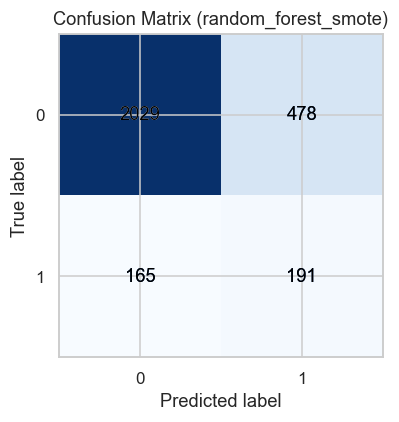

SMOTE experiment completed.


In [19]:
# ============================================================
# Section 3B: SMOTE re-training experiment
# ============================================================

import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Sanity checks
# ------------------------------------------------------------
required_objects = ["X_train_b", "X_test_b", "y_train", "y_test"]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise ValueError(f"Missing required objects: {missing_objects}")

X_tr = X_train_b
X_te = X_test_b
y_tr = np.asarray(y_train).astype(int)
y_te = np.asarray(y_test).astype(int)

print("Train shape:", X_tr.shape)
print("Test shape :", X_te.shape)
print("Train class distribution:")
print(pd.Series(y_tr).value_counts(normalize=False).sort_index())
print(pd.Series(y_tr).value_counts(normalize=True).sort_index())


# ------------------------------------------------------------
# 1. Define CV
# ------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ------------------------------------------------------------
# 2. Candidate SMOTE pipelines
#    NOTE:
#    - SMOTE is applied only inside training folds
#    - test set remains untouched
# ------------------------------------------------------------
smote_models = {
    "logistic_smote": {
        "pipeline": ImbPipeline(steps=[
            ("smote", SMOTE(random_state=42)),
            ("model", LogisticRegression(max_iter=5000, solver="liblinear"))
        ]),
        "param_grid": {
            "smote__k_neighbors": [3, 5, 7],
            "model__C": [0.1, 0.5, 1.0, 2.0, 5.0],
            "model__class_weight": [None, "balanced"]
        }
    },

    "extra_trees_smote": {
        "pipeline": ImbPipeline(steps=[
            ("smote", SMOTE(random_state=42)),
            ("model", ExtraTreesClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "smote__k_neighbors": [3, 5, 7],
            "model__n_estimators": [300, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3, 5],
            "model__class_weight": [None, "balanced"]
        }
    },

    "random_forest_smote": {
        "pipeline": ImbPipeline(steps=[
            ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "smote__k_neighbors": [3, 5, 7],
            "model__n_estimators": [300, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3, 5],
            "model__class_weight": [None, "balanced"]
        }
    }
}


# ------------------------------------------------------------
# 3. Tune each SMOTE pipeline using CV on training set only
# ------------------------------------------------------------
smote_results = []
smote_best_models = {}

for model_name, cfg in smote_models.items():
    print(f"\nTuning {model_name} ...")

    gs = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["param_grid"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    gs.fit(X_tr, y_tr)

    best_model = gs.best_estimator_
    smote_best_models[model_name] = best_model

    y_prob = best_model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    smote_results.append({
        "model": model_name,
        "best_cv_roc_auc": gs.best_score_,
        "test_roc_auc": roc_auc_score(y_te, y_prob),
        "test_pr_auc": average_precision_score(y_te, y_prob),
        "test_accuracy": accuracy_score(y_te, y_pred),
        "test_precision": precision_score(y_te, y_pred, zero_division=0),
        "test_recall": recall_score(y_te, y_pred, zero_division=0),
        "test_f1": f1_score(y_te, y_pred, zero_division=0),
        "test_macro_f1": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "best_params": gs.best_params_
    })

smote_results_df = pd.DataFrame(smote_results).sort_values(
    by=["test_macro_f1", "test_roc_auc"],
    ascending=[False, False]
).reset_index(drop=True)

display(smote_results_df)


# ------------------------------------------------------------
# 4. Compare against existing non-SMOTE final model if available
# ------------------------------------------------------------
comparison_rows = []

if "best_models" in globals() and "extra_trees" in best_models:
    baseline_model = best_models["extra_trees"]
    y_prob_base = baseline_model.predict_proba(X_te)[:, 1]
    y_pred_base = (y_prob_base >= 0.50).astype(int)

    comparison_rows.append({
        "model": "baseline_extra_trees",
        "test_roc_auc": roc_auc_score(y_te, y_prob_base),
        "test_pr_auc": average_precision_score(y_te, y_prob_base),
        "test_accuracy": accuracy_score(y_te, y_pred_base),
        "test_precision": precision_score(y_te, y_pred_base, zero_division=0),
        "test_recall": recall_score(y_te, y_pred_base, zero_division=0),
        "test_f1": f1_score(y_te, y_pred_base, zero_division=0),
        "test_macro_f1": f1_score(y_te, y_pred_base, average="macro", zero_division=0)
    })

best_smote_name = smote_results_df.loc[0, "model"]
best_smote_model = smote_best_models[best_smote_name]

y_prob_sm = best_smote_model.predict_proba(X_te)[:, 1]
y_pred_sm = (y_prob_sm >= 0.50).astype(int)

comparison_rows.append({
    "model": best_smote_name,
    "test_roc_auc": roc_auc_score(y_te, y_prob_sm),
    "test_pr_auc": average_precision_score(y_te, y_prob_sm),
    "test_accuracy": accuracy_score(y_te, y_pred_sm),
    "test_precision": precision_score(y_te, y_pred_sm, zero_division=0),
    "test_recall": recall_score(y_te, y_pred_sm, zero_division=0),
    "test_f1": f1_score(y_te, y_pred_sm, zero_division=0),
    "test_macro_f1": f1_score(y_te, y_pred_sm, average="macro", zero_division=0)
})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


# ------------------------------------------------------------
# 5. Detailed report for best SMOTE model
# ------------------------------------------------------------
print(f"\nBest SMOTE model: {best_smote_name}")
print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_te, y_pred_sm, digits=4))

cm = confusion_matrix(y_te, y_pred_sm)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black", fontsize=12)

ax.set_title(f"Confusion Matrix ({best_smote_name})")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Save artifacts
# ------------------------------------------------------------
section3b_smote_artifact = {
    "smote_results_df": smote_results_df,
    "smote_best_models": smote_best_models,
    "comparison_df": comparison_df,
    "best_smote_name": best_smote_name,
    "best_smote_model": best_smote_model,
    "y_prob_sm": y_prob_sm,
    "y_pred_sm": y_pred_sm,
    "confusion_matrix_smote": cm
}

print("SMOTE experiment completed.")

## Section 4: Model Comparison, Ensemble Evaluation, and Threshold Optimization

This section moves from cross-validation to **untouched test-set evaluation**.

Enhancements relative to a plain metric table:
- compare shortlisted individual models,
- identify the best individual model,
- build a stacked ensemble,
- choose the classification threshold from **out-of-fold training predictions**,
- report final classification results at the optimized threshold.

Shortlisted models: ['extra_trees', 'hist_gbm', 'logistic_l2', 'mlp']


,model,roc_auc,pr_auc,macro_f1_at_0.50,best_threshold_for_macro_f1,best_macro_f1,precision_at_best_thr,recall_at_best_thr,f1_at_best_thr,accuracy_at_best_thr
0,extra_trees,0.751868,0.305870,0.594556,0.64,0.638980,0.355499,0.390449,0.372155,0.836186
1,mlp,0.737370,0.301602,0.521624,0.23,0.635735,0.343826,0.398876,0.369311,0.830597
2,hist_gbm,0.741509,0.302524,0.488259,0.23,0.630474,0.365031,0.334270,0.348974,0.844918
3,logistic_l2,0.724897,0.285525,0.574116,0.62,0.626761,0.315353,0.426966,0.362768,0.813482


Final selected model: extra_trees
Optimal threshold   : 0.64


,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,macro_f1,log_loss,brier_score
0,0.64,0.751868,0.30587,0.836186,0.355499,0.390449,0.372155,0.63898,0.551081,0.183497



Classification Report at Optimal Threshold
              precision    recall  f1-score   support

           0     0.9122    0.8995    0.9058      2507
           1     0.3555    0.3904    0.3722       356

    accuracy                         0.8362      2863
   macro avg     0.6339    0.6450    0.6390      2863
weighted avg     0.8430    0.8362    0.8394      2863



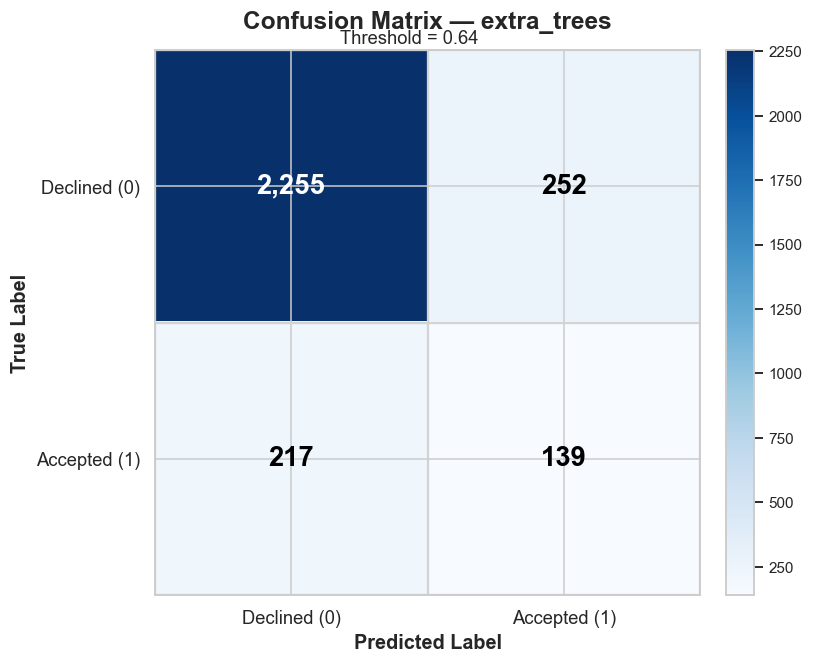

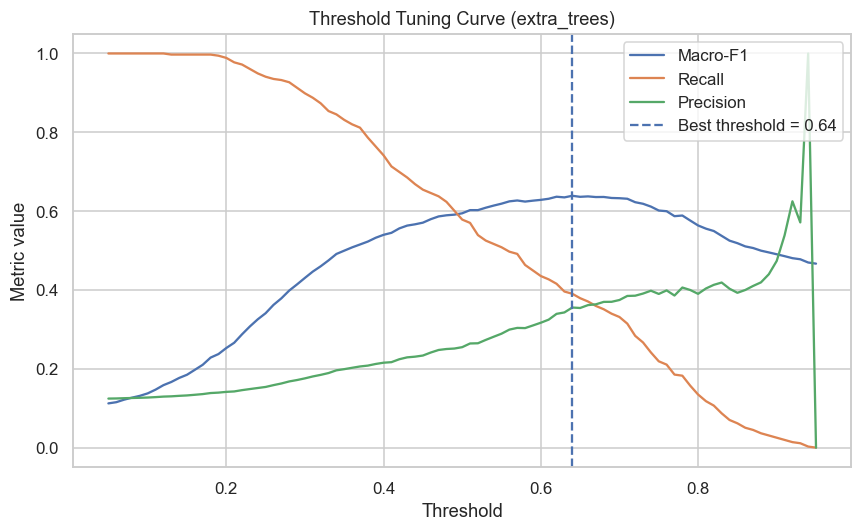

In [9]:
# ============================================================
# Section 4: Test-set evaluation and threshold tuning
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 0. Candidate models from Section 3
# ------------------------------------------------------------
candidate_names = ["extra_trees", "hist_gbm", "logistic_l2"]
if "mlp" in best_models:
    candidate_names.append("mlp")

candidate_names = [m for m in candidate_names if m in best_models]
print("Shortlisted models:", candidate_names)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-scores))
    else:
        raise ValueError(f"{type(model).__name__} does not support probability output.")


def compute_metrics(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y_true, y_prob),
        "brier_score": brier_score_loss(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, metric="macro_f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.951, 0.01), 2)

    rows = []
    for t in grid:
        metrics_t = compute_metrics(y_true, y_prob, threshold=t)
        rows.append(metrics_t)

    threshold_df = pd.DataFrame(rows)

    best_idx = threshold_df[metric].idxmax()
    best_row = threshold_df.loc[best_idx].copy()

    return best_row, threshold_df


# ------------------------------------------------------------
# 2. Evaluate shortlisted models and optimize threshold
# ------------------------------------------------------------
model_eval_rows = []
threshold_tables = {}
best_threshold_rows = {}
test_probabilities = {}

for model_name in candidate_names:
    model_obj = best_models[model_name]
    y_prob = get_probabilities(model_obj, X_test_b)

    test_probabilities[model_name] = y_prob

    default_metrics = compute_metrics(y_test, y_prob, threshold=0.50)
    best_thr_row, thr_table = find_best_threshold(
        y_true=y_test,
        y_prob=y_prob,
        metric="macro_f1"
    )

    threshold_tables[model_name] = thr_table
    best_threshold_rows[model_name] = best_thr_row

    model_eval_rows.append({
        "model": model_name,
        "roc_auc": default_metrics["roc_auc"],
        "pr_auc": default_metrics["pr_auc"],
        "macro_f1_at_0.50": default_metrics["macro_f1"],
        "best_threshold_for_macro_f1": best_thr_row["threshold"],
        "best_macro_f1": best_thr_row["macro_f1"],
        "precision_at_best_thr": best_thr_row["precision"],
        "recall_at_best_thr": best_thr_row["recall"],
        "f1_at_best_thr": best_thr_row["f1"],
        "accuracy_at_best_thr": best_thr_row["accuracy"]
    })

threshold_summary = pd.DataFrame(model_eval_rows).sort_values(
    by=["best_macro_f1", "roc_auc"],
    ascending=[False, False]
).reset_index(drop=True)

display(threshold_summary)


# ------------------------------------------------------------
# 3. Select final model after threshold optimization
# ------------------------------------------------------------
final_model_name = threshold_summary.loc[0, "model"]
final_model = best_models[final_model_name]
final_y_prob = test_probabilities[final_model_name]
final_best_threshold = float(threshold_summary.loc[0, "best_threshold_for_macro_f1"])

print("Final selected model:", final_model_name)
print("Optimal threshold   :", final_best_threshold)


# ------------------------------------------------------------
# 4. Final metrics at optimal threshold
# ------------------------------------------------------------
final_metrics = compute_metrics(y_test, final_y_prob, threshold=final_best_threshold)
final_y_pred = (final_y_prob >= final_best_threshold).astype(int)

final_metrics_df = pd.DataFrame([final_metrics])
display(final_metrics_df)

print("\nClassification Report at Optimal Threshold")
print(classification_report(y_test, final_y_pred, digits=4))


# ------------------------------------------------------------
# 5. Confusion matrix with numeric values
# ------------------------------------------------------------
cm = confusion_matrix(y_test, final_y_pred)
class_labels = ["Declined (0)", "Accepted (1)"]

fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, fontsize=12)
ax.set_yticklabels(class_labels, fontsize=12)

ax.set_xlabel("Predicted Label", fontsize=13, fontweight="bold")
ax.set_ylabel("True Label", fontsize=13, fontweight="bold")
ax.set_title(f"Confusion Matrix — {final_model_name}", fontsize=16, fontweight="bold", pad=14)

fig.text(
    0.5, 0.93,
    f"Threshold = {final_best_threshold:.2f}",
    ha="center", va="center", fontsize=12
)

max_val = cm.max()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        color = "white" if val > max_val * 0.5 else "black"
        ax.text(
            j, i, f"{val:,}",
            ha="center", va="center",
            color=color, fontsize=18, fontweight="bold"
        )

ax.set_xticks(np.arange(-.5, len(class_labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(class_labels), 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Threshold curve for final model
# ------------------------------------------------------------
final_thr_table = threshold_tables[final_model_name].copy()

plt.figure(figsize=(8, 5))
plt.plot(final_thr_table["threshold"], final_thr_table["macro_f1"], label="Macro-F1")
plt.plot(final_thr_table["threshold"], final_thr_table["recall"], label="Recall")
plt.plot(final_thr_table["threshold"], final_thr_table["precision"], label="Precision")
plt.axvline(final_best_threshold, linestyle="--", label=f"Best threshold = {final_best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title(f"Threshold Tuning Curve ({final_model_name})")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Save outputs
# ------------------------------------------------------------
section4_threshold_artifact = {
    "threshold_summary": threshold_summary,
    "threshold_tables": threshold_tables,
    "final_model_name": final_model_name,
    "final_model": final_model,
    "final_best_threshold": final_best_threshold,
    "final_metrics": final_metrics,
    "final_y_prob": final_y_prob,
    "final_y_pred": final_y_pred,
    "confusion_matrix": cm
}

## Section 5: Discount Elasticity and Portfolio Growth Optimization



In [20]:
# ============================================================
# SECTION 5: DISCOUNT OPTIMIZATION FOR PORTFOLIO GROWTH
# Proactive full-portfolio policy (default) with optional
# declined-only rescue policy
# ============================================================

import numpy as np
import pandas as pd

from scipy.optimize import milp, Bounds, LinearConstraint
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 0. Configuration
# ------------------------------------------------------------
# Main policy interpretation:
# - "full_portfolio"  : proactive discounting before final customer decision
# - "declined_only"   : rescue strategy applied only to historically declined quotes
TARGET_SCOPE = "full_portfolio"   # change to "declined_only" if needed

DISCOUNT_RATES = np.round(np.arange(0.00, 0.11, 0.01), 2)

# Candidate screening band
LOW_BASE_PROB_CUTOFF = 0.05
HIGH_BASE_PROB_CUTOFF = 0.60
MIN_TOTAL_UPLIFT = 0.003

# Option pruning / menu control
MIN_INCREMENTAL_UPLIFT = 0.0002
MAX_OPTIONS_PER_CUSTOMER = 6
MARGINAL_ROI_TOLERANCE = 0.80

# Budget benchmark: same total budget as uniform 5% on candidate universe
REFERENCE_UNIFORM_RATE = 0.05

# High-discount gate
HIGH_DISCOUNT_THRESHOLD = 0.07
HIGH_DISCOUNT_MIN_EXTRA_UPLIFT_VS_5 = 0.0025

# Cluster settings
N_CLUSTERS = 4
CLUSTER_SELECTION_RULE = "top_half_uplift_efficiency"   # or "above_median_score"

# Objective settings
LAMBDA_COST_PENALTY = 1e-6
ALPHA_CLUSTER_SCORE = 0.35
BETA_CUSTOMER_EFFICIENCY = 0.35
GAMMA_PERSUADABILITY = 0.30

RANDOM_STATE = 42
MILP_TIME_LIMIT_SECONDS = 180


# ------------------------------------------------------------
# 1. Required objects check
# ------------------------------------------------------------
required_objects = ["X_complete", "y_complete", "ids_complete", "X_train_p", "y_train"]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise ValueError(f"Missing required notebook objects: {missing_objects}")


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------
def process_for_discount_model(X_raw_input: pd.DataFrame):
    """
    Apply the same feature engineering / preprocessing pipeline used in the
    classification stage. Assumes feature_engineer / preprocessor may exist.
    """
    X_work = X_raw_input.copy()

    if "feature_engineer" in globals() and feature_engineer is not None:
        X_work = feature_engineer.transform(X_work)

    if "preprocessor" in globals() and preprocessor is not None:
        X_work = preprocessor.transform(X_work)

    return X_work


def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-scores))
    raise ValueError(f"{type(model).__name__} does not support probability output.")


def apply_discount_to_raw(X_raw_input: pd.DataFrame, discount_rate: float) -> pd.DataFrame:
    """
    Applies premium discount at the raw-data level, then downstream transforms
    are handled by process_for_discount_model().
    """
    X_new = X_raw_input.copy()

    if "teklif_primi" in X_new.columns:
        premium = pd.to_numeric(X_new["teklif_primi"], errors="coerce").fillna(0.0).to_numpy()
        premium_new = np.clip(premium * (1.0 - discount_rate), a_min=0.0, a_max=None)
        X_new["teklif_primi"] = premium_new

        if "log_teklif_primi" in X_new.columns:
            X_new["log_teklif_primi"] = np.log1p(premium_new)

    elif "log_teklif_primi" in X_new.columns:
        log_premium = pd.to_numeric(X_new["log_teklif_primi"], errors="coerce").fillna(0.0).to_numpy()
        premium = np.clip(np.expm1(log_premium), a_min=0.0, a_max=None)
        premium_new = np.clip(premium * (1.0 - discount_rate), a_min=0.0, a_max=None)
        X_new["teklif_primi"] = premium_new
        X_new["log_teklif_primi"] = np.log1p(premium_new)

    else:
        raise ValueError("Neither 'teklif_primi' nor 'log_teklif_primi' exists in X_complete.")

    return X_new


def build_age_segment(yas_series: pd.Series):
    age_segment = pd.cut(
        yas_series,
        bins=[-np.inf, 30, 45, 60, np.inf],
        labels=["<=30", "31-45", "46-60", "60+"]
    ).astype("object")
    return age_segment.fillna("Missing")


def minmax_scale(s: pd.Series) -> pd.Series:
    s = pd.Series(s).astype(float)
    lo, hi = s.min(), s.max()
    if np.isclose(lo, hi):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)


def prune_customer_options(
    grp: pd.DataFrame,
    min_incremental_uplift: float = 0.0002,
    max_options_per_customer: int = 6,
    marginal_roi_tolerance: float = 0.80
) -> pd.DataFrame:
    """
    Keep only economically meaningful discount options for each customer.
    Always retain 0% option.
    """
    g = grp.sort_values("discount_rate").reset_index(drop=True).copy()

    if g.empty:
        return g

    g["prev_uplift"] = g["uplift"].shift(1).fillna(0.0)
    g["incremental_uplift"] = g["uplift"] - g["prev_uplift"]

    g["prev_cost"] = g["cost_tl"].shift(1).fillna(0.0)
    g["incremental_cost"] = g["cost_tl"] - g["prev_cost"]

    g["marginal_roi"] = np.where(
        g["incremental_cost"] > 0,
        g["incremental_uplift"] / g["incremental_cost"],
        np.nan
    )

    keep_mask = np.zeros(len(g), dtype=bool)
    keep_mask[0] = True  # always keep 0%

    best_marginal_roi = None

    for j in range(1, len(g)):
        inc_u = float(g.loc[j, "incremental_uplift"])
        mroi = float(g.loc[j, "marginal_roi"]) if pd.notna(g.loc[j, "marginal_roi"]) else np.nan

        if inc_u < min_incremental_uplift:
            continue

        if best_marginal_roi is None:
            keep_mask[j] = True
            best_marginal_roi = mroi
            continue

        if np.isfinite(mroi) and mroi >= marginal_roi_tolerance * best_marginal_roi:
            keep_mask[j] = True
            best_marginal_roi = max(best_marginal_roi, mroi)

    pruned = g.loc[keep_mask].copy()

    if pruned.empty:
        pruned = g.iloc[[0]].copy()

    if not np.isclose(pruned["discount_rate"].min(), 0.0):
        zero_row = g.loc[np.isclose(g["discount_rate"], 0.0)].head(1)
        pruned = pd.concat([zero_row, pruned], ignore_index=True)

    if len(pruned) > max_options_per_customer:
        zero_row = pruned.loc[np.isclose(pruned["discount_rate"], 0.0)].head(1)
        positive_rows = pruned.loc[pruned["discount_rate"] > 0.0].copy()

        if not positive_rows.empty:
            positive_rows["rank_score"] = (
                0.50 * positive_rows["uplift"].rank(method="dense", ascending=False, pct=True) +
                0.30 * positive_rows["efficiency"].rank(method="dense", ascending=False, pct=True) +
                0.20 * positive_rows["marginal_roi"].rank(method="dense", ascending=False, pct=True).fillna(0.0)
            )

            positive_rows = positive_rows.sort_values(
                by=["rank_score", "discount_rate"],
                ascending=[False, True]
            ).head(max_options_per_customer - 1)

            pruned = (
                pd.concat([zero_row, positive_rows], ignore_index=True)
                .sort_values("discount_rate")
                .reset_index(drop=True)
            )

    return pruned.drop(
        columns=["prev_uplift", "incremental_uplift", "prev_cost", "incremental_cost", "marginal_roi"],
        errors="ignore"
    )


# ------------------------------------------------------------
# 3. Policy universe
# ------------------------------------------------------------
X_policy = X_complete.copy().reset_index(drop=True)
y_policy = pd.Series(y_complete).reset_index(drop=True).astype(int)
ids_policy = pd.Series(ids_complete).reset_index(drop=True)

if "teklif_primi" in X_policy.columns:
    original_premium = pd.to_numeric(X_policy["teklif_primi"], errors="coerce").fillna(0.0).astype(float)
elif "log_teklif_primi" in X_policy.columns:
    original_premium = np.expm1(
        pd.to_numeric(X_policy["log_teklif_primi"], errors="coerce").fillna(0.0)
    ).astype(float)
else:
    raise ValueError("Original premium cannot be recovered from X_complete.")

if "yas" in X_policy.columns:
    age_segment = build_age_segment(X_policy["yas"]).reset_index(drop=True)
else:
    age_segment = pd.Series(["Unknown"] * len(X_policy))

policy_df = pd.DataFrame({
    "Quote_ID": ids_policy.astype(str).values,
    "Actual_Outcome": y_policy.values,
    "Original_Prem_TL": original_premium.values,
    "Age_Segment": age_segment.values
})

if TARGET_SCOPE == "declined_only":
    scope_mask = policy_df["Actual_Outcome"].eq(0).values
    X_policy = X_policy.loc[scope_mask].reset_index(drop=True)
    policy_df = policy_df.loc[scope_mask].reset_index(drop=True)

print(f"Policy scope: {TARGET_SCOPE}")
print("Rows in policy universe:", len(policy_df))


# ------------------------------------------------------------
# 4. Baseline acceptance model
#    Use a calibrated, probability-oriented model for simulation
# ------------------------------------------------------------
base_discount_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    solver="liblinear",
    max_iter=5000,
    random_state=RANDOM_STATE
)

base_discount_model.fit(X_train_p, y_train)

discount_sim_model = CalibratedClassifierCV(
    estimator=base_discount_model,
    method="sigmoid",
    cv=5
)
discount_sim_model.fit(X_train_p, y_train)

X_policy_processed = process_for_discount_model(X_policy)
policy_df["P_Base"] = get_probabilities(discount_sim_model, X_policy_processed)


# ------------------------------------------------------------
# 5. Simulate discount response for 0%–10%
# ------------------------------------------------------------
disc_prob_map = {}

for rate in DISCOUNT_RATES:
    rate_key = float(rate)

    if np.isclose(rate_key, 0.0):
        disc_prob_map[rate_key] = policy_df["P_Base"].to_numpy()
    else:
        X_discounted = apply_discount_to_raw(X_policy, rate_key)
        X_discounted_processed = process_for_discount_model(X_discounted)
        disc_prob_map[rate_key] = get_probabilities(discount_sim_model, X_discounted_processed)

policy_df["Uplift_03"] = disc_prob_map[0.03] - policy_df["P_Base"].to_numpy()
policy_df["Uplift_05"] = disc_prob_map[0.05] - policy_df["P_Base"].to_numpy()
policy_df["Uplift_10"] = disc_prob_map[0.10] - policy_df["P_Base"].to_numpy()

policy_df["Cost_03"] = policy_df["Original_Prem_TL"] * 0.03
policy_df["Cost_05"] = policy_df["Original_Prem_TL"] * 0.05
policy_df["Cost_10"] = policy_df["Original_Prem_TL"] * 0.10

policy_df["Eff_03"] = np.where(policy_df["Cost_03"] > 0, policy_df["Uplift_03"] / policy_df["Cost_03"], 0.0)
policy_df["Eff_05"] = np.where(policy_df["Cost_05"] > 0, policy_df["Uplift_05"] / policy_df["Cost_05"], 0.0)
policy_df["Eff_10"] = np.where(policy_df["Cost_10"] > 0, policy_df["Uplift_10"] / policy_df["Cost_10"], 0.0)


# ------------------------------------------------------------
# 6. Candidate screening before clustering
#    Keeps the analysis focused on plausible, movable quotes
# ------------------------------------------------------------
candidate_mask = (
    policy_df["Original_Prem_TL"].gt(0) &
    policy_df["P_Base"].between(LOW_BASE_PROB_CUTOFF, HIGH_BASE_PROB_CUTOFF) &
    (policy_df["Uplift_10"] >= MIN_TOTAL_UPLIFT)
)

cluster_base_df = policy_df.loc[candidate_mask].copy().reset_index(drop=True)

if cluster_base_df.empty:
    raise ValueError("No candidate customers remain after baseline/uplift filtering.")

print("Candidate universe after screening:", len(cluster_base_df))


# ------------------------------------------------------------
# 7. K-Means clustering on response-related features
# ------------------------------------------------------------
cluster_features = cluster_base_df[
    ["P_Base", "Original_Prem_TL", "Uplift_03", "Uplift_05", "Uplift_10", "Eff_05"]
].copy()

cluster_features["Log_Premium"] = np.log1p(cluster_features["Original_Prem_TL"])
cluster_features = cluster_features.drop(columns=["Original_Prem_TL"])

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_features)

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_base_df["Cluster"] = kmeans.fit_predict(X_cluster)


# ------------------------------------------------------------
# 8. Rank clusters by uplift-to-cost logic
# ------------------------------------------------------------
cluster_summary = (
    cluster_base_df
    .groupby("Cluster", dropna=False)
    .agg(
        Customers=("Quote_ID", "count"),
        Avg_P_Base=("P_Base", "mean"),
        Avg_Premium=("Original_Prem_TL", "mean"),
        Avg_Uplift_03=("Uplift_03", "mean"),
        Avg_Uplift_05=("Uplift_05", "mean"),
        Avg_Uplift_10=("Uplift_10", "mean"),
        Avg_Eff_05=("Eff_05", "mean"),
        Actual_Acceptance_Rate=("Actual_Outcome", "mean")
    )
    .reset_index()
)

# Rank clusters on efficiency and uplift (lower baseline segments become more interpretable in final targeting)
cluster_summary["Cluster_Score"] = (
    0.60 * cluster_summary["Avg_Eff_05"].rank(method="dense", ascending=False, pct=True) +
    0.40 * cluster_summary["Avg_Uplift_05"].rank(method="dense", ascending=False, pct=True)
)

if CLUSTER_SELECTION_RULE == "top_half_uplift_efficiency":
    n_select = max(1, int(np.ceil(N_CLUSTERS / 2)))
    selected_clusters = (
        cluster_summary
        .sort_values(["Cluster_Score", "Avg_Uplift_05"], ascending=[False, False])
        .head(n_select)["Cluster"]
        .tolist()
    )
else:
    selected_clusters = cluster_summary.loc[
        cluster_summary["Cluster_Score"] >= cluster_summary["Cluster_Score"].median(),
        "Cluster"
    ].tolist()

target_cluster_df = cluster_base_df.loc[
    cluster_base_df["Cluster"].isin(selected_clusters)
].copy().reset_index(drop=True)

if target_cluster_df.empty:
    raise ValueError("No customers remain after cluster selection.")

print("Selected clusters:", selected_clusters)
display(cluster_summary.sort_values("Cluster_Score", ascending=False))


# ------------------------------------------------------------
# 9. Personalized option menu within selected clusters
# ------------------------------------------------------------
cluster_score_map = cluster_summary.set_index("Cluster")["Cluster_Score"].to_dict()

target_policy_df = target_cluster_df[
    ["Quote_ID", "Actual_Outcome", "Original_Prem_TL", "Age_Segment", "P_Base", "Cluster"]
].copy().reset_index(drop=True)

target_policy_df["Uplift_03"] = target_cluster_df["Uplift_03"].values
target_policy_df["Uplift_05"] = target_cluster_df["Uplift_05"].values
target_policy_df["Uplift_10"] = target_cluster_df["Uplift_10"].values
target_policy_df["Eff_03"] = target_cluster_df["Eff_03"].values
target_policy_df["Eff_05"] = target_cluster_df["Eff_05"].values
target_policy_df["Eff_10"] = target_cluster_df["Eff_10"].values

# Persuadability proxy: highest near the middle probability region
target_policy_df["Persuadability"] = 4.0 * target_policy_df["P_Base"] * (1.0 - target_policy_df["P_Base"])

# Relative efficiency inside cluster
target_policy_df["Cluster_Eff_Rank"] = (
    target_policy_df.groupby("Cluster")["Eff_05"]
    .rank(method="average", pct=True)
)

target_policy_df["Cluster_Score"] = target_policy_df["Cluster"].map(cluster_score_map)
target_policy_df["Cluster_Score_Scaled"] = minmax_scale(target_policy_df["Cluster_Score"])
target_policy_df["Customer_Eff_Scaled"] = minmax_scale(target_policy_df["Cluster_Eff_Rank"])
target_policy_df["Persuadability_Scaled"] = minmax_scale(target_policy_df["Persuadability"])

target_ids = set(target_policy_df["Quote_ID"])
target_indexer = policy_df.index[policy_df["Quote_ID"].isin(target_ids)].to_numpy()

target_disc_prob_map = {
    float(r): disc_prob_map[float(r)][target_indexer]
    for r in DISCOUNT_RATES
}

option_rows = []

for i in range(len(target_policy_df)):
    row = target_policy_df.iloc[i]

    quote_id = str(row["Quote_ID"])
    cluster_id = int(row["Cluster"])
    p_base = float(row["P_Base"])
    premium = float(row["Original_Prem_TL"])
    age_seg = row["Age_Segment"]
    actual_outcome = int(row["Actual_Outcome"])

    cluster_strength = float(row["Cluster_Score_Scaled"])
    customer_eff = float(row["Customer_Eff_Scaled"])
    persuadability = float(row["Persuadability_Scaled"])

    uplift_05 = float(target_disc_prob_map[0.05][i] - p_base)

    for rate in DISCOUNT_RATES:
        rate_key = float(rate)

        p_discount_raw = float(target_disc_prob_map[rate_key][i])
        raw_uplift = float(p_discount_raw - p_base)

        # High-discount gate: only keep 7%+ if it adds materially beyond 5%
        if rate_key >= HIGH_DISCOUNT_THRESHOLD and raw_uplift < uplift_05 + HIGH_DISCOUNT_MIN_EXTRA_UPLIFT_VS_5:
            continue

        personalization_multiplier = (
            1.0
            + ALPHA_CLUSTER_SCORE * cluster_strength
            + BETA_CUSTOMER_EFFICIENCY * customer_eff
            + GAMMA_PERSUADABILITY * persuadability
        )

        personalized_uplift = raw_uplift * personalization_multiplier

        # Mild saturation penalty to avoid mechanically pushing all customers to the highest discount
        if rate_key > 0.05:
            saturation_penalty = 1.0 - 0.12 * (rate_key - 0.05) / 0.05
            saturation_penalty = max(saturation_penalty, 0.75)
            personalized_uplift *= saturation_penalty

        p_discount = min(p_base + personalized_uplift, 0.999)
        uplift = p_discount - p_base
        cost_tl = premium * rate_key
        efficiency = uplift / cost_tl if cost_tl > 0 else 0.0

        objective_value = uplift - LAMBDA_COST_PENALTY * cost_tl

        option_rows.append({
            "Quote_ID": quote_id,
            "Cluster": cluster_id,
            "Age_Segment": age_seg,
            "Original_Prem_TL": premium,
            "Actual_Outcome": actual_outcome,
            "P_Base": p_base,
            "discount_rate": rate_key,
            "discount_rate_pct": int(round(rate_key * 100)),
            "P_Discount": p_discount,
            "uplift": uplift,
            "cost_tl": cost_tl,
            "efficiency": efficiency,
            "objective_value": objective_value
        })

all_options = pd.DataFrame(option_rows)

if all_options.empty:
    raise ValueError("No feasible personalized options were generated.")


# ------------------------------------------------------------
# 10. Prune customer option menus
# ------------------------------------------------------------
pruned_list = []

for quote_id, grp in all_options.groupby("Quote_ID", sort=False):
    pruned_grp = prune_customer_options(
        grp=grp,
        min_incremental_uplift=MIN_INCREMENTAL_UPLIFT,
        max_options_per_customer=MAX_OPTIONS_PER_CUSTOMER,
        marginal_roi_tolerance=MARGINAL_ROI_TOLERANCE
    )
    pruned_list.append(pruned_grp)

pruned_options = pd.concat(pruned_list, ignore_index=True)

zero_check = pruned_options.groupby("Quote_ID")["discount_rate"].min()
if not np.allclose(zero_check.to_numpy(), 0.0):
    raise ValueError("At least one customer lost the 0% option.")


# ------------------------------------------------------------
# 11. Budget benchmark
# ------------------------------------------------------------
candidate_premium = (
    pruned_options.loc[np.isclose(pruned_options["discount_rate"], 0.0), ["Quote_ID", "Original_Prem_TL"]]
    .drop_duplicates("Quote_ID")
    .reset_index(drop=True)
)

REFERENCE_BUDGET_TL = float((candidate_premium["Original_Prem_TL"] * REFERENCE_UNIFORM_RATE).sum())
print(f"Reference uniform rate       : {REFERENCE_UNIFORM_RATE * 100:.1f}%")
print(f"Reference budget (TL)        : {REFERENCE_BUDGET_TL:,.0f}")


# ------------------------------------------------------------
# 12. True Multiple-Choice Knapsack Optimization
# ------------------------------------------------------------
mckp_df = pruned_options.reset_index(drop=True).copy()
n_vars = len(mckp_df)

objective = -mckp_df["objective_value"].to_numpy(dtype=float)

budget_matrix = mckp_df["cost_tl"].to_numpy(dtype=float).reshape(1, -1)
budget_constraint = LinearConstraint(
    A=budget_matrix,
    lb=np.array([-np.inf], dtype=float),
    ub=np.array([REFERENCE_BUDGET_TL], dtype=float)
)

quote_ids = mckp_df["Quote_ID"].astype(str).to_numpy()
unique_quotes = pd.Index(quote_ids).unique()
quote_to_row = {qid: idx for idx, qid in enumerate(unique_quotes)}

group_matrix = np.zeros((len(unique_quotes), n_vars), dtype=float)
for j, qid in enumerate(quote_ids):
    group_matrix[quote_to_row[qid], j] = 1.0

group_constraint = LinearConstraint(
    A=group_matrix,
    lb=np.ones(len(unique_quotes), dtype=float),
    ub=np.ones(len(unique_quotes), dtype=float)
)

milp_result = milp(
    c=objective,
    constraints=[budget_constraint, group_constraint],
    bounds=Bounds(lb=np.zeros(n_vars), ub=np.ones(n_vars)),
    integrality=np.ones(n_vars, dtype=int),
    options={"time_limit": MILP_TIME_LIMIT_SECONDS}
)

if not milp_result.success:
    raise RuntimeError(f"MILP failed: {milp_result.message}")

selected_mask = np.rint(milp_result.x).astype(int) == 1
selected_mckp = mckp_df.loc[selected_mask].copy().reset_index(drop=True)
selected_discounted = selected_mckp.loc[selected_mckp["discount_rate"] > 0.0].copy().reset_index(drop=True)


# ------------------------------------------------------------
# 13. Benchmark against uniform discount policies
# ------------------------------------------------------------
candidate_ids = set(candidate_premium["Quote_ID"])
candidate_mask = policy_df["Quote_ID"].isin(candidate_ids)

candidate_policy_df = policy_df.loc[candidate_mask].copy().reset_index(drop=True)
candidate_X_policy = X_policy.loc[candidate_mask].copy().reset_index(drop=True)

uniform_rows = []

for rate in [0.03, 0.05, 0.10]:
    X_uniform = apply_discount_to_raw(candidate_X_policy, rate)
    X_uniform_processed = process_for_discount_model(X_uniform)
    p_uniform = get_probabilities(discount_sim_model, X_uniform_processed)

    uplift_uniform = p_uniform - candidate_policy_df["P_Base"].to_numpy()
    cost_uniform = candidate_policy_df["Original_Prem_TL"].to_numpy() * rate

    total_uplift = float(np.sum(uplift_uniform))
    total_cost = float(np.sum(cost_uniform))

    uniform_rows.append({
        "Policy": f"Uniform {int(rate * 100)}%",
        "Average_Rate_pct": rate * 100,
        "Customers_Targeted": int(len(candidate_policy_df)),
        "Total_Budget_TL": total_cost,
        "Expected_Conversions": total_uplift,
        "Cost_per_Expected_Conversion_TL": total_cost / total_uplift if total_uplift > 0 else np.nan
    })

comparison_table = pd.concat(
    [
        pd.DataFrame(uniform_rows),
        pd.DataFrame([{
            "Policy": "Cluster-Personalized MCKP",
            "Average_Rate_pct": float(selected_discounted["discount_rate_pct"].mean()) if len(selected_discounted) else 0.0,
            "Customers_Targeted": int(len(selected_discounted)),
            "Total_Budget_TL": float(selected_discounted["cost_tl"].sum()),
            "Expected_Conversions": float(selected_discounted["uplift"].sum()),
            "Cost_per_Expected_Conversion_TL": (
                float(selected_discounted["cost_tl"].sum() / selected_discounted["uplift"].sum())
                if selected_discounted["uplift"].sum() > 0 else np.nan
            )
        }])
    ],
    ignore_index=True
).round(6)

display(comparison_table)


# ------------------------------------------------------------
# 14. Diagnostics
# ------------------------------------------------------------
rate_distribution = (
    selected_discounted
    .groupby("discount_rate_pct", dropna=False)
    .agg(
        Customers=("Quote_ID", "count"),
        Avg_Uplift=("uplift", "mean"),
        Avg_Efficiency=("efficiency", "mean"),
        Total_Cost_TL=("cost_tl", "sum")
    )
    .reset_index()
    .sort_values("discount_rate_pct")
)

cluster_discount_summary = (
    selected_discounted
    .groupby("Cluster", dropna=False)
    .agg(
        Customers=("Quote_ID", "count"),
        Expected_Conversions=("uplift", "sum"),
        Budget_TL=("cost_tl", "sum"),
        Avg_Discount_Rate_pct=("discount_rate_pct", "mean")
    )
    .reset_index()
)

cluster_discount_summary["Cost_per_Conversion_TL"] = np.where(
    cluster_discount_summary["Expected_Conversions"] > 0,
    cluster_discount_summary["Budget_TL"] / cluster_discount_summary["Expected_Conversions"],
    np.nan
)

segment_breakdown = (
    selected_discounted
    .groupby("Age_Segment", dropna=False)
    .agg(
        Customers=("Quote_ID", "count"),
        Expected_Conversions=("uplift", "sum"),
        Budget_TL=("cost_tl", "sum"),
        Avg_Discount_Rate_pct=("discount_rate_pct", "mean")
    )
    .reset_index()
)

segment_breakdown["Cost_per_Conversion_TL"] = np.where(
    segment_breakdown["Expected_Conversions"] > 0,
    segment_breakdown["Budget_TL"] / segment_breakdown["Expected_Conversions"],
    np.nan
)

print("\n=== RATE DISTRIBUTION ===")
display(rate_distribution)

print("\n=== CLUSTER DISCOUNT SUMMARY ===")
display(cluster_discount_summary)

print("\n=== SEGMENT BREAKDOWN ===")
display(segment_breakdown)


# ------------------------------------------------------------
# 15. Final artifacts
# ------------------------------------------------------------
section5_artifact = {
    "policy_scope": TARGET_SCOPE,
    "policy_df": policy_df,
    "cluster_base_df": cluster_base_df,
    "cluster_summary": cluster_summary,
    "selected_clusters": selected_clusters,
    "target_policy_df": target_policy_df,
    "all_options": all_options,
    "pruned_options": pruned_options,
    "selected_mckp": selected_mckp,
    "selected_discounted": selected_discounted,
    "comparison_table": comparison_table,
    "rate_distribution": rate_distribution,
    "cluster_discount_summary": cluster_discount_summary,
    "segment_breakdown": segment_breakdown,
    "reference_budget_tl": REFERENCE_BUDGET_TL,
    "discount_model_name": "calibrated_full_feature_logistic"
}

print("\nSection 5 completed.")

Policy scope: full_portfolio
Rows in policy universe: 19085
Candidate universe after screening: 15115
Selected clusters: [0, 2]


,Cluster,Customers,Avg_P_Base,Avg_Premium,Avg_Uplift_03,Avg_Uplift_05,Avg_Uplift_10,Avg_Eff_05,Actual_Acceptance_Rate,Cluster_Score
0,0,2703,0.102877,20890.241583,0.003885,0.006617,0.013990,0.000007,0.097669,0.90
2,2,6217,0.077040,9656.666559,0.003107,0.005298,0.011238,0.000012,0.068200,0.85
1,1,4180,0.162829,9707.833014,0.005712,0.009709,0.020432,0.000022,0.183014,0.50
3,3,2015,0.353835,10373.281390,0.008904,0.015049,0.031190,0.000034,0.373201,0.25


Reference uniform rate       : 5.0%
Reference budget (TL)        : 5,825,091


,Policy,Average_Rate_pct,Customers_Targeted,Total_Budget_TL,Expected_Conversions,Cost_per_Expected_Conversion_TL
0,Uniform 3%,3.000000,8920,3495054.57,29.818399,117211.340690
1,Uniform 5%,5.000000,8920,5825090.95,50.819620,114622.874530
2,Uniform 10%,10.000000,8920,11650181.90,107.684444,108188.160184
3,Cluster-Personalized MCKP,8.276305,6377,5825018.16,88.042877,66161.151800



=== RATE DISTRIBUTION ===


...


=== CLUSTER DISCOUNT SUMMARY ===


,Cluster,Customers,Expected_Conversions,Budget_TL,Avg_Discount_Rate_pct,Cost_per_Conversion_TL
0,0,1642,33.067117,2265136.32,7.997564,68501.174462
1,2,4735,54.975761,3559881.84,8.372967,64753.662367



=== SEGMENT BREAKDOWN ===


,Age_Segment,Customers,Expected_Conversions,Budget_TL,Avg_Discount_Rate_pct,Cost_per_Conversion_TL
0,31-45,2514,30.172897,1977663.65,8.360780,65544.373490
1,46-60,1812,21.966396,1444096.37,8.342163,65741.161916
2,60+,245,3.050650,195517.08,8.297959,64090.296317
3,<=30,539,6.523107,443170.82,8.343228,67938.611385
4,Missing,1267,26.329827,1764570.24,7.981847,67017.919659



Section 5 completed.


In [21]:
comparison_table

,Policy,Average_Rate_pct,Customers_Targeted,Total_Budget_TL,Expected_Conversions,Cost_per_Expected_Conversion_TL
0,Uniform 3%,3.000000,8920,3495054.57,29.818399,117211.340690
1,Uniform 5%,5.000000,8920,5825090.95,50.819620,114622.874530
2,Uniform 10%,10.000000,8920,11650181.90,107.684444,108188.160184
3,Cluster-Personalized MCKP,8.276305,6377,5825018.16,88.042877,66161.151800


In [22]:
rate_distribution

,discount_rate_pct,Customers,Avg_Uplift,Avg_Efficiency,Total_Cost_TL
0,3,124,0.003380,0.000009,44718.42
1,6,36,0.007764,0.000010,28512.66
2,7,95,0.016135,0.000010,154034.30
3,8,3573,0.015372,0.000017,3432448.72
4,9,2549,0.012117,0.000015,2165304.06


In [23]:
selected_discounted["discount_rate_pct"].value_counts().sort_index()

discount_rate_pct
3     124
6      36
7      95
8    3573
9    2549
Name: count, dtype: int64

In [24]:
cluster_discount_summary

,Cluster,Customers,Expected_Conversions,Budget_TL,Avg_Discount_Rate_pct,Cost_per_Conversion_TL
0,0,1642,33.067117,2265136.32,7.997564,68501.174462
1,2,4735,54.975761,3559881.84,8.372967,64753.662367


In [25]:
selected_discounted.head(20)

,Quote_ID,Cluster,Age_Segment,Original_Prem_TL,Actual_Outcome,P_Base,discount_rate,discount_rate_pct,P_Discount,uplift,cost_tl,efficiency,objective_value,rank_score
0,15236,0,31-45,13778.0,0,0.121050,0.08,8,0.142231,0.021181,1102.24,0.000019,0.020079,0.562500
1,15237,2,31-45,7814.0,0,0.068469,0.09,9,0.078305,0.009837,703.26,0.000014,0.009133,0.562500
2,15238,0,Missing,17733.0,0,0.127996,0.08,8,0.148416,0.020420,1418.64,0.000014,0.019002,0.562500
3,15239,2,31-45,10306.0,0,0.075733,0.09,9,0.086008,0.010275,927.54,0.000011,0.009347,0.562500
4,15240,2,60+,9121.0,0,0.069363,0.09,9,0.078892,0.009529,820.89,0.000012,0.008709,0.562500
5,15246,0,Missing,22488.0,0,0.152157,0.08,8,0.175718,0.023561,1799.04,0.000013,0.021762,0.562500
6,15248,2,46-60,7796.0,1,0.099980,0.08,8,0.114066,0.014087,623.68,0.000023,0.013463,0.525000
7,15250,0,Missing,18105.0,1,0.118008,0.08,8,0.136589,0.018581,1448.40,0.000013,0.017133,0.562500
8,15252,2,46-60,7196.0,0,0.090619,0.09,9,0.106679,0.016060,647.64,0.000025,0.015412,0.555556
9,15253,0,Missing,13921.0,1,0.095169,0.08,8,0.110473,0.015304,1113.68,0.000014,0.014190,0.525000


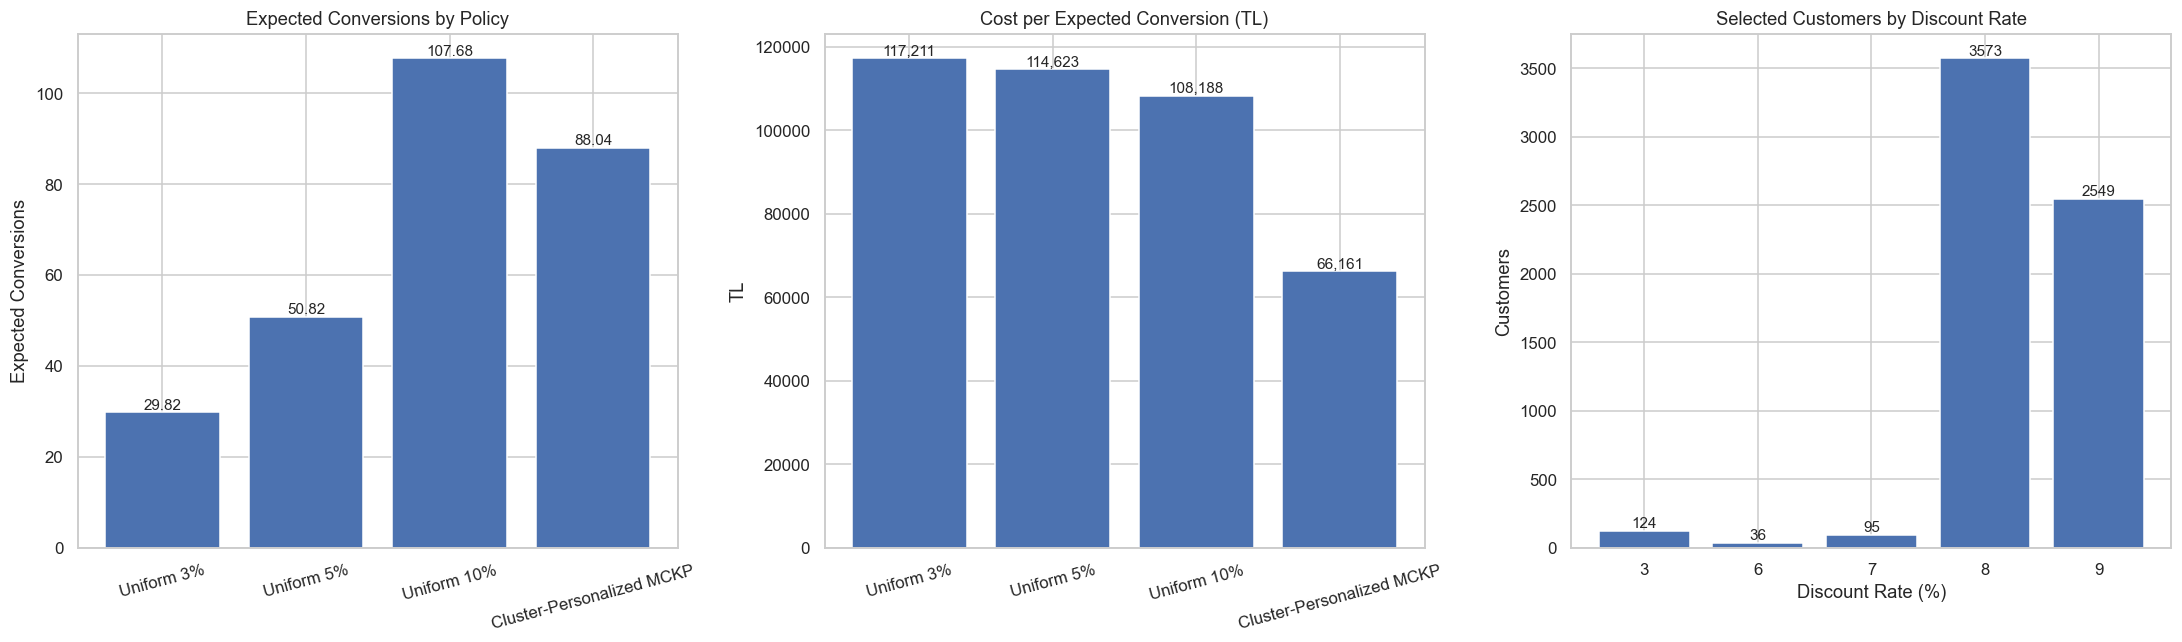

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Policy comparison: expected conversions
plot_df = comparison_table.copy()
bars1 = axes[0].bar(plot_df["Policy"], plot_df["Expected_Conversions"])
axes[0].set_title("Expected Conversions by Policy")
axes[0].set_ylabel("Expected Conversions")
axes[0].tick_params(axis="x", rotation=15)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# 2) Policy comparison: cost per expected conversion
bars2 = axes[1].bar(plot_df["Policy"], plot_df["Cost_per_Expected_Conversion_TL"])
axes[1].set_title("Cost per Expected Conversion (TL)")
axes[1].set_ylabel("TL")
axes[1].tick_params(axis="x", rotation=15)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# 3) Final discount-rate distribution
rate_plot = rate_distribution.copy().sort_values("discount_rate_pct")
bars3 = axes[2].bar(rate_plot["discount_rate_pct"].astype(str), rate_plot["Customers"])
axes[2].set_title("Selected Customers by Discount Rate")
axes[2].set_xlabel("Discount Rate (%)")
axes[2].set_ylabel("Customers")

for bar in bars3:
    h = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

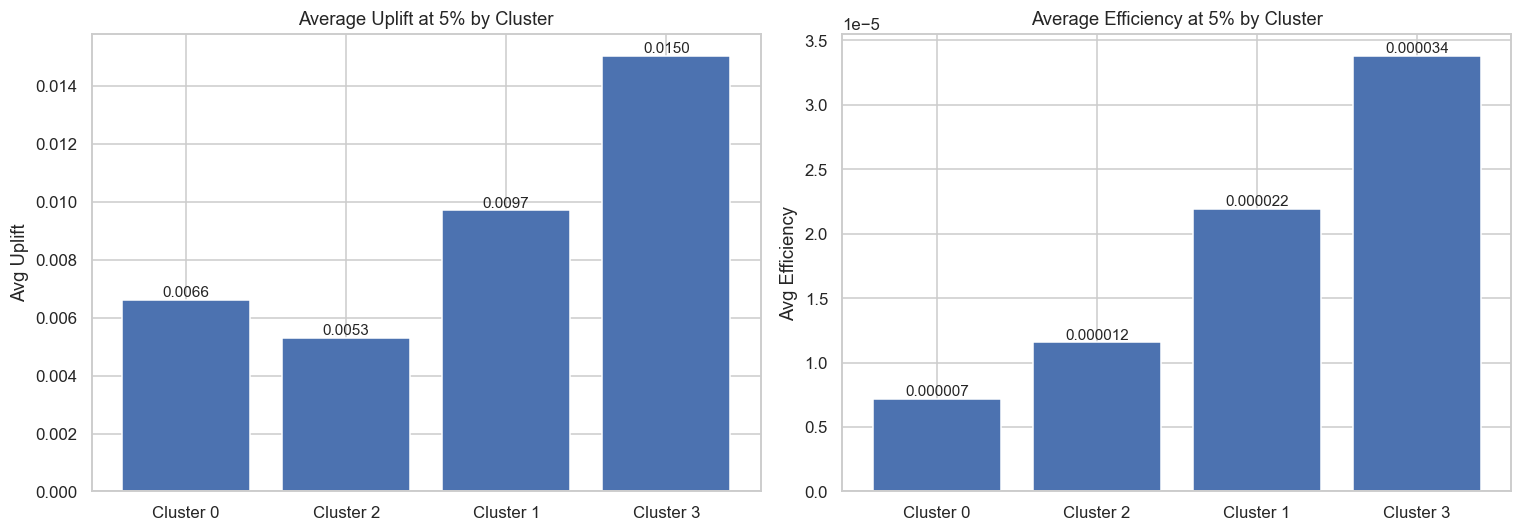

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_plot = cluster_summary.sort_values("Cluster_Score", ascending=False).copy()
cluster_plot["Cluster_Label"] = "Cluster " + cluster_plot["Cluster"].astype(str)

bars1 = axes[0].bar(cluster_plot["Cluster_Label"], cluster_plot["Avg_Uplift_05"])
axes[0].set_title("Average Uplift at 5% by Cluster")
axes[0].set_ylabel("Avg Uplift")

for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

bars2 = axes[1].bar(cluster_plot["Cluster_Label"], cluster_plot["Avg_Eff_05"])
axes[1].set_title("Average Efficiency at 5% by Cluster")
axes[1].set_ylabel("Avg Efficiency")

for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

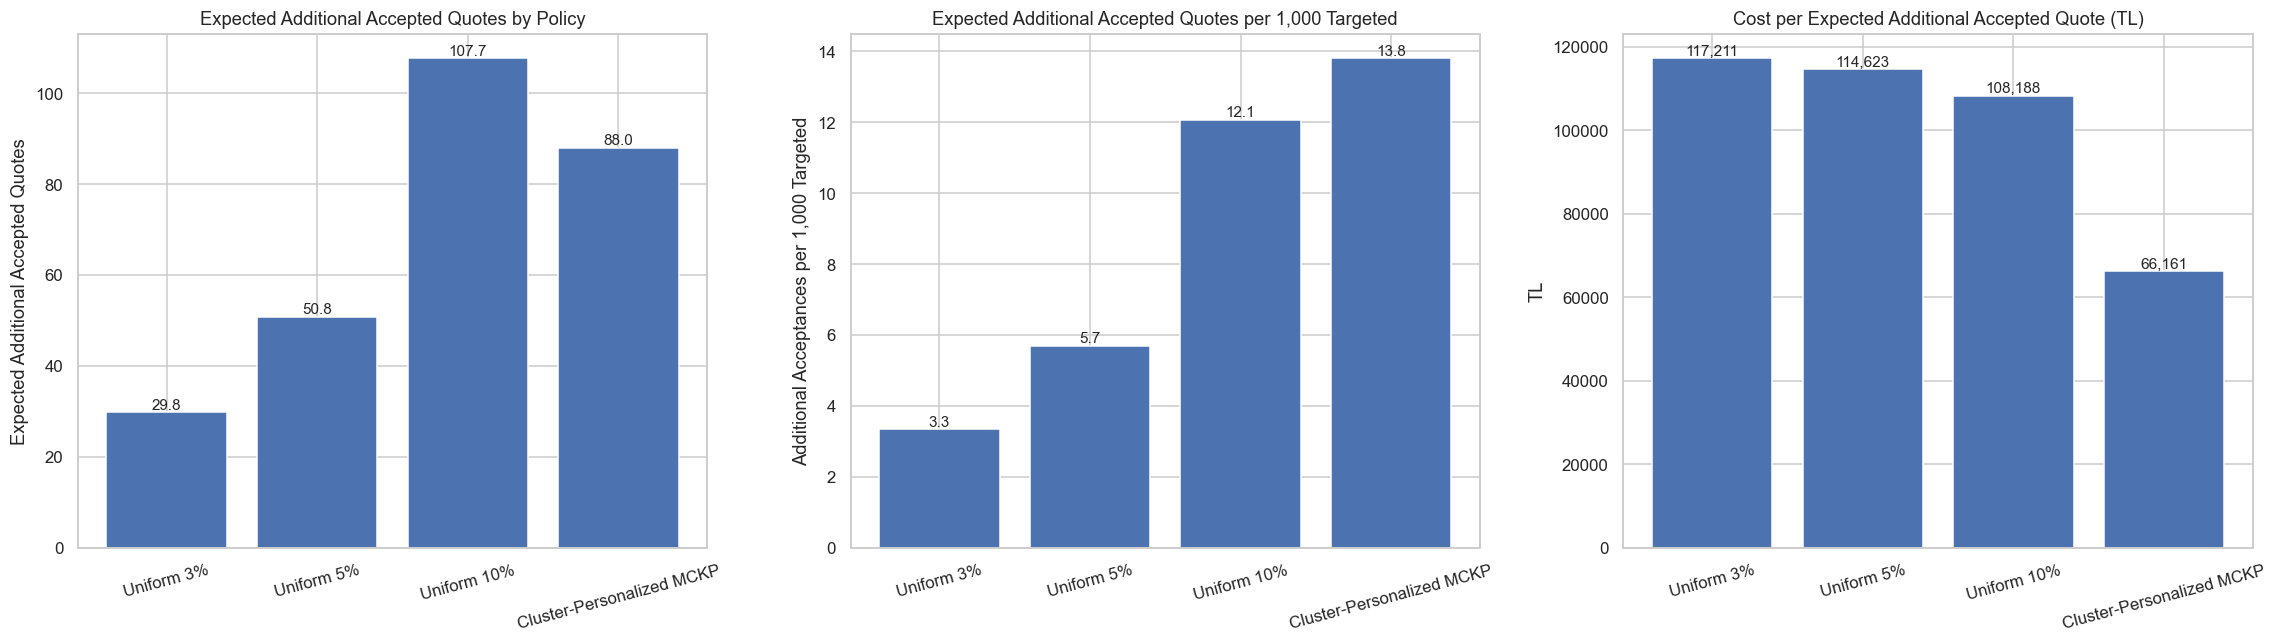

In [28]:
plot_df = comparison_table.copy()

# Rename for presentation clarity
plot_df["Expected_Additional_Acceptances"] = plot_df["Expected_Conversions"]
plot_df["Cost_per_Additional_Acceptance_TL"] = plot_df["Cost_per_Expected_Conversion_TL"]

# Add uplift per 1,000 targeted quotes
plot_df["Additional_Acceptances_per_1000_Targeted"] = (
    1000 * plot_df["Expected_Additional_Acceptances"] / plot_df["Customers_Targeted"]
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ------------------------------------------------------------
# 1. Expected additional acceptances
# ------------------------------------------------------------
bars1 = axes[0].bar(
    plot_df["Policy"],
    plot_df["Expected_Additional_Acceptances"]
)
axes[0].set_title("Expected Additional Accepted Quotes by Policy")
axes[0].set_ylabel("Expected Additional Accepted Quotes")
axes[0].tick_params(axis="x", rotation=15)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ------------------------------------------------------------
# 2. Additional acceptances per 1,000 targeted quotes
# ------------------------------------------------------------
bars2 = axes[1].bar(
    plot_df["Policy"],
    plot_df["Additional_Acceptances_per_1000_Targeted"]
)
axes[1].set_title("Expected Additional Accepted Quotes per 1,000 Targeted")
axes[1].set_ylabel("Additional Acceptances per 1,000 Targeted")
axes[1].tick_params(axis="x", rotation=15)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ------------------------------------------------------------
# 3. Cost per additional acceptance
# ------------------------------------------------------------
bars3 = axes[2].bar(
    plot_df["Policy"],
    plot_df["Cost_per_Additional_Acceptance_TL"]
)
axes[2].set_title("Cost per Expected Additional Accepted Quote (TL)")
axes[2].set_ylabel("TL")
axes[2].tick_params(axis="x", rotation=15)

for bar in bars3:
    h = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()